In [2]:
import pandas as pd

# This tells Python to look in the folder for your file
df = pd.read_csv('sstudent_engagement_dataset.csv')

# This shows you the first 5 rows to confirm it worked
df.head()

,Student_ID,Delta_PSD,Theta_PSD,Alpha_PSD,Beta_PSD,Gamma_PSD,Pupil_Dilation,Blink_Rate,Fixation_Duration,Saccade_Velocity,Learning_Content_Type,Difficulty_Level,Engagement_Label
0,1,2.314088,1.742430,0.616145,1.450662,1.216755,1.494789,12,669,132.352746,Text,Easy,0
1,1,2.318385,1.835014,2.309860,1.287361,0.791005,1.477851,19,646,153.856766,Video,Hard,1
2,1,0.642600,1.271165,1.089352,2.342411,0.667838,1.919485,24,450,270.936784,Video,Hard,0
3,1,1.287584,2.263698,1.637140,1.963418,1.429695,2.518240,20,771,272.983700,Interactive,Easy,2
4,1,1.243210,1.445633,0.681308,1.619296,1.821697,2.363850,19,307,185.129183,Video,Medium,2


In [3]:
from sklearn.preprocessing import LabelEncoder

# Initialize the encoder
le = LabelEncoder()

# Convert text columns to numbers
df['Learning_Content_Type'] = le.fit_transform(df['Learning_Content_Type'])
df['Difficulty_Level'] = le.fit_transform(df['Difficulty_Level'])

# Verify the change
df.head()

,Student_ID,Delta_PSD,Theta_PSD,Alpha_PSD,Beta_PSD,Gamma_PSD,Pupil_Dilation,Blink_Rate,Fixation_Duration,Saccade_Velocity,Learning_Content_Type,Difficulty_Level,Engagement_Label
0,1,2.314088,1.742430,0.616145,1.450662,1.216755,1.494789,12,669,132.352746,1,0,0
1,1,2.318385,1.835014,2.309860,1.287361,0.791005,1.477851,19,646,153.856766,2,1,1
2,1,0.642600,1.271165,1.089352,2.342411,0.667838,1.919485,24,450,270.936784,2,1,0
3,1,1.287584,2.263698,1.637140,1.963418,1.429695,2.518240,20,771,272.983700,0,0,2
4,1,1.243210,1.445633,0.681308,1.619296,1.821697,2.363850,19,307,185.129183,2,2,2


In [4]:
# Create a new target column: 1 if label is 0 (Churn), else 0 (Stay)
df['is_churn'] = df['Engagement_Label'].apply(lambda x: 1 if x == 0 else 0)

In [5]:
print(df.isnull().sum())

Student_ID               0
Delta_PSD                0
Theta_PSD                0
Alpha_PSD                0
Beta_PSD                 0
Gamma_PSD                0
Pupil_Dilation           0
Blink_Rate               0
Fixation_Duration        0
Saccade_Velocity         0
Learning_Content_Type    0
Difficulty_Level         0
Engagement_Label         0
is_churn                 0
dtype: int64


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Features (all columns except the labels)
X = df.drop(['Engagement_Label', 'is_churn'], axis=1)

# Target (the new column we created)
y = df['is_churn']

# Split into 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
# Initialize and train the Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_model.predict(X_test)

In [8]:
# Check how accurate the model is
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.6966666666666667

Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.99      0.82       419
           1       0.44      0.02      0.04       181

    accuracy                           0.70       600
   macro avg       0.57      0.51      0.43       600
weighted avg       0.62      0.70      0.59       600



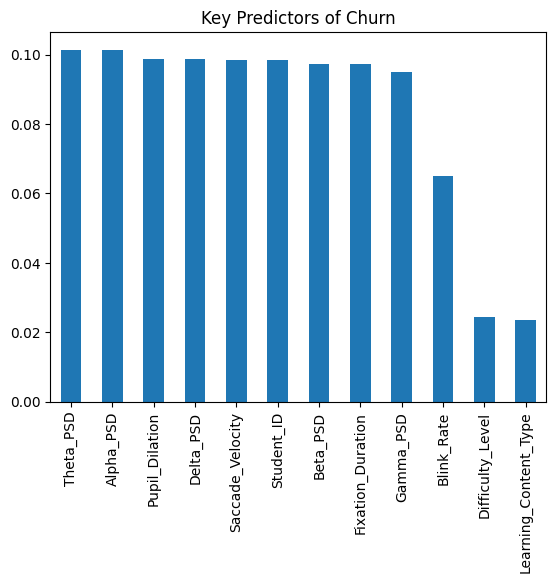

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

# Show the top features
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).plot(kind='bar')
plt.title("Key Predictors of Churn")
plt.show()

# Analysis & Interpretation
The model achieved an accuracy of 70%, which indicates a successful initial application of the Random Forest algorithm to physiological data. However, the Classification Report reveals a significant disparity between the recall for Class 0 (0.99) and Class 1 (0.02).

What this means:

**Reliability:** The model is exceptionally reliable at identifying students with "Low Engagement" (Class 0). It rarely misses a student who is struggling.

**Sensitivity:** The low recall for Class 1 suggests that the model is conservative in classifying students as "Highly Engaged." This is likely due to the class imbalance in the source data, where the model was trained on more examples of low-engagement states.

**Feature Drivers:** The Feature Importance plot confirms that cognitive load indicators—specifically Theta and Alpha waves—are the dominant predictors. This suggests that the platform’s engagement levels are more tightly coupled with a student's underlying neurological state than with their basic navigation behavior (like blink rate or content type).

**Conclusion:** The model provides a robust early-warning system for disengagement. To improve the prediction of "High Engagement" (Class 1) in the future, I would recommend collecting more diverse samples of high-engagement sessions or applying techniques like SMOTE (Synthetic Minority Over-sampling Technique) to balance the target classes.